## 1. Data cleaning and pre-processing

In [1]:
import pandas as pd

cargoterminal_el_demand = pd.read_excel("inputs/cargoterminal_el_demand.xlsx")

In [2]:
# Take first two columns, exclude first data row after header,
# rename columns, and parse datetime
cargoterminal_el_demand = (
    cargoterminal_el_demand.iloc[1:, [0, 1]]
      .copy()
      .rename(columns={cargoterminal_el_demand.columns[0]: "datetime", cargoterminal_el_demand.columns[1]: "ampere"})
)
cargoterminal_el_demand["datetime"] = pd.to_datetime(
    cargoterminal_el_demand["datetime"], errors="coerce"
)
cargoterminal_el_demand["ampere"] = pd.to_numeric(
    cargoterminal_el_demand["ampere"], errors="coerce"
)

In [3]:
cargoterminal_el_demand.head()

,datetime,ampere
1,2025-03-01 00:15:00,13.0
2,2025-03-01 00:30:00,12.0
3,2025-03-01 00:45:00,12.0
4,2025-03-01 01:00:00,13.0
5,2025-03-01 01:15:00,12.0


In [4]:
cargoterminal_el_demand.tail()

,datetime,ampere
35035,2026-02-28 22:45:00,14.0
35036,2026-02-28 23:00:00,14.0
35037,2026-02-28 23:15:00,14.0
35038,2026-02-28 23:30:00,14.0
35039,2026-02-28 23:45:00,14.0


Since the given dataset is from March 2025 to February 2026, the January and February 2026 data is taken and shifted at the beginning of the dataset as it was 2025.

In [5]:
# Build a Jan-Dec 2025 series by moving Jan/Feb 2026 to Jan/Feb 2025
df_months_shift = cargoterminal_el_demand.copy()

mask_jan_feb_2026 = (
    (df_months_shift["datetime"].dt.year == 2026) &
    (df_months_shift["datetime"].dt.month.isin([1, 2]))
)

# Jan/Feb 2026 -> Jan/Feb 2025
part_jf_2025 = df_months_shift.loc[mask_jan_feb_2026].copy()
part_jf_2025["datetime"] = part_jf_2025["datetime"] - pd.DateOffset(years=1)

# Keep Mar-Dec 2025
part_mar_dec_2025 = df_months_shift.loc[
    (df_months_shift["datetime"].dt.year == 2025) &
    (df_months_shift["datetime"].dt.month >= 3)
].copy()

# Final dataset: Jan 2025 ... Dec 2025
cargoterminal_el_demand = (
    pd.concat([part_jf_2025, part_mar_dec_2025], ignore_index=True)
      .sort_values("datetime")
      .reset_index(drop=True)
)

# Optional quick checks
print(cargoterminal_el_demand["datetime"].min())
print(cargoterminal_el_demand["datetime"].max())
print(cargoterminal_el_demand["datetime"].dt.year.value_counts())

2025-01-01 00:00:00
2025-12-31 23:45:00
datetime
2025    35039
Name: count, dtype: int64


Converting to kWh for visualization

In [6]:
cargoterminal_el_demand_hourly = (
    cargoterminal_el_demand
    .dropna(subset=["datetime", "ampere"])
    .set_index("datetime")
    .sort_index()
    .resample("h")["ampere"]
    .sum()
    .mul(10) # multiply by voltage (10 kV)
    .mul(0.95) # multiply by power factor
    .mul(0.25) # convert to kWh
    .reset_index()
    .rename(columns={"ampere": "energy_kWh"})
)

cargoterminal_el_demand_hourly.head()

,datetime,energy_kWh
0,2025-01-01 00:00:00,152.000
1,2025-01-01 01:00:00,149.625
2,2025-01-01 02:00:00,147.250
3,2025-01-01 03:00:00,149.625
4,2025-01-01 04:00:00,147.250


In [7]:
# Copy and normalize datetime
ft = cargoterminal_el_demand_hourly.copy()
ft["datetime"] = pd.to_datetime(ft["datetime"], errors="coerce")
ft = ft.dropna(subset=["datetime"]).sort_values("datetime")

# Pick power column (adjust if your column name differs)
power_col = "energy_kWh"  # e.g. "demand_kW" if that is your actual column

# Ensure numeric
ft[power_col] = pd.to_numeric(ft[power_col], errors="coerce").fillna(0.0)

# For hourly data: energy (kWh) = sum(kW * 1h)
total_kwh = (ft[power_col] * 1.0).sum()

print(f"Total consumption: {total_kwh:,.2f} kWh")

Total consumption: 767,374.38 kWh


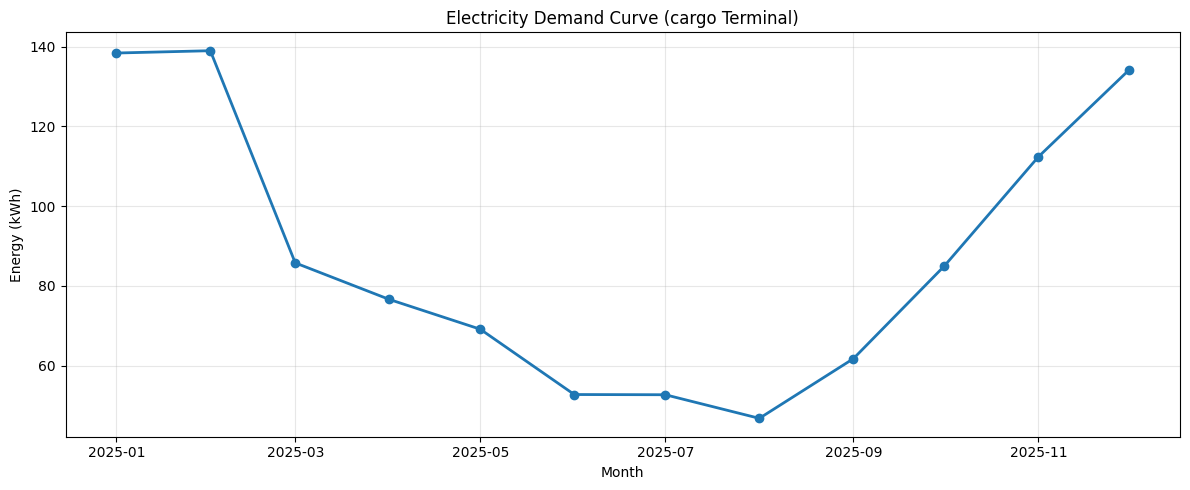

In [8]:
import matplotlib.pyplot as plt

# Ensure datetime index
df_plot = cargoterminal_el_demand_hourly.dropna(subset=["datetime", "energy_kWh"]).copy()
df_plot = df_plot.set_index("datetime").sort_index()

# Monthly demand curve (average energy per month)
monthly_curve = df_plot["energy_kWh"].resample("MS").mean()  # MS = month start

plt.figure(figsize=(12, 5))
plt.plot(monthly_curve.index, monthly_curve.values, marker="o", linewidth=2)
plt.title("Electricity Demand Curve (cargo Terminal)")
plt.xlabel("Month")
plt.ylabel("Energy (kWh)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

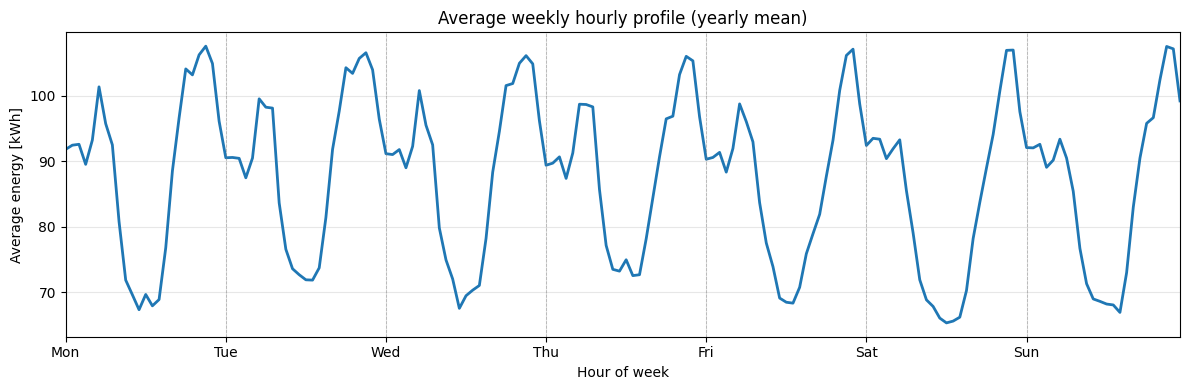

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = cargoterminal_el_demand_hourly.copy()

# 1) Ensure datetime type
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
df = df.dropna(subset=["datetime"])

# 2) Build hour-of-week index: Monday 00:00 = 0, ..., Sunday 23:00 = 167
df["hour_of_week"] = df["datetime"].dt.dayofweek * 24 + df["datetime"].dt.hour

# 3) Yearly average profile per hour-of-week (168 points)
weekly_profile = (
    df.groupby("hour_of_week")["energy_kWh"]
      .mean()
      .reindex(range(168))  # keep full week order
      .reset_index(name="avg_energy_kWh")
)

# 4) Plot one-week average hourly profile
plt.figure(figsize=(12, 4))
plt.plot(weekly_profile["hour_of_week"], weekly_profile["avg_energy_kWh"], linewidth=2)

# Day separators and labels
day_starts = [0, 24, 48, 72, 96, 120, 144]
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
for x in day_starts:
    plt.axvline(x=x, color="gray", linestyle="--", linewidth=0.6, alpha=0.5)

plt.xticks(day_starts, day_labels)
plt.xlim(0, 167)
plt.xlabel("Hour of week")
plt.ylabel("Average energy [kWh]")
plt.title("Average weekly hourly profile (yearly mean)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Converting to kW

In [10]:
from math import sqrt

cargoterminal_power_demand = (
    cargoterminal_el_demand
    .dropna(subset=["datetime", "ampere"])
    .set_index("datetime")
    .sort_index()
    .mul(10) # multiply by voltage (10 kV)
    .mul(0.95) # multiply by power factor
    .mul(sqrt(3)) # multiply by sqrt(3) for 3-phase system
    .reset_index()
    .rename(columns={"ampere": "power_kW"})
)

cargoterminal_power_demand.head()


,datetime,power_kW
0,2025-01-01 00:00:00,263.271723
1,2025-01-01 00:15:00,263.271723
2,2025-01-01 00:30:00,263.271723
3,2025-01-01 00:45:00,263.271723
4,2025-01-01 01:00:00,263.271723


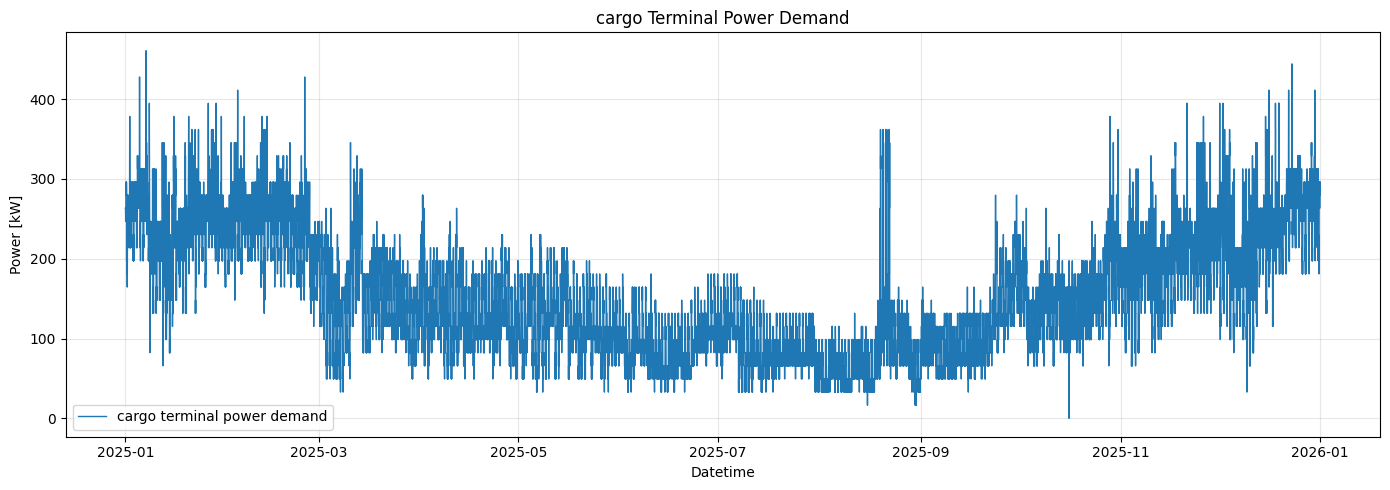

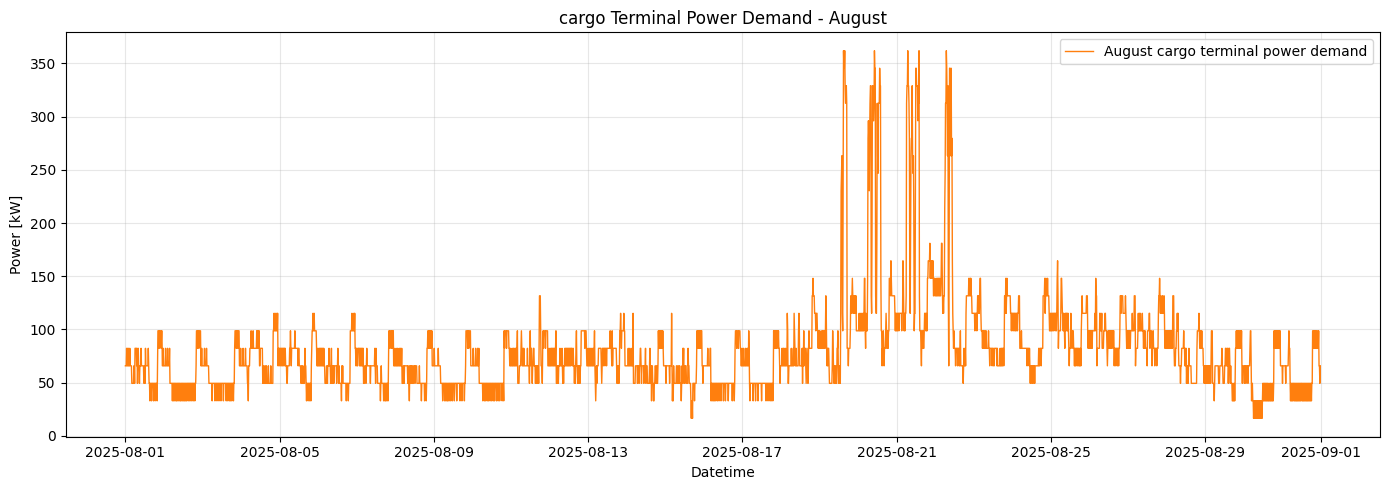

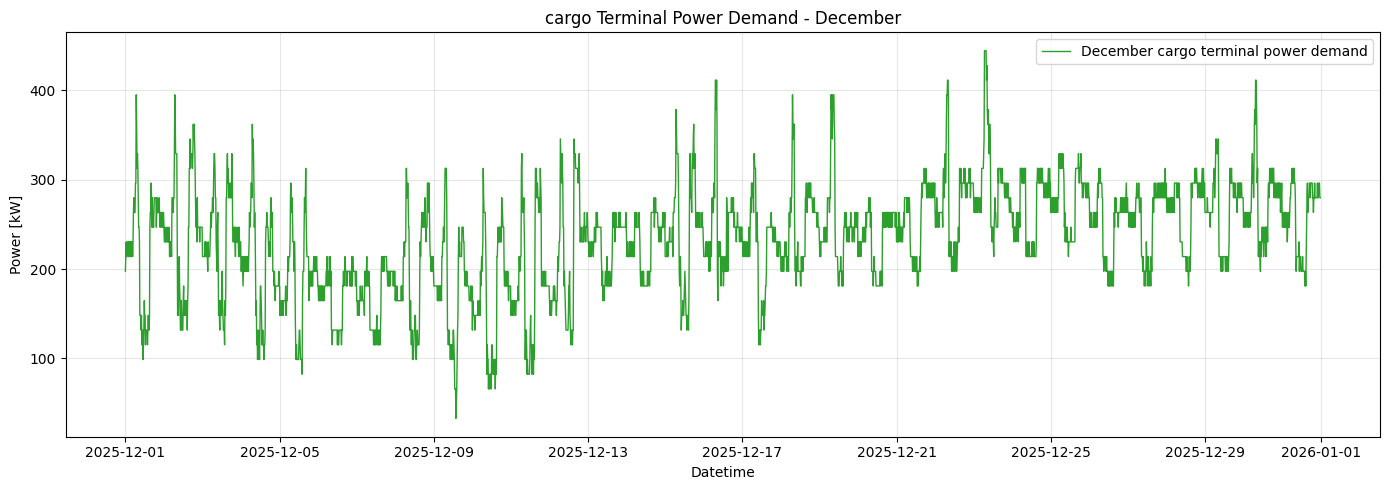

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure datetime is parsed and sorted
df_plot = cargoterminal_power_demand.copy()
df_plot["datetime"] = pd.to_datetime(df_plot["datetime"], errors="coerce")
df_plot = df_plot.dropna(subset=["datetime", "power_kW"]).sort_values("datetime")

# Full period plot
plt.figure(figsize=(14, 5))
plt.plot(df_plot["datetime"], df_plot["power_kW"], linewidth=1.0, label="cargo terminal power demand")
plt.title("cargo Terminal Power Demand")
plt.xlabel("Datetime")
plt.ylabel("Power [kW]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# August zoom-in plot
df_august = df_plot[df_plot["datetime"].dt.month == 8]

plt.figure(figsize=(14, 5))
plt.plot(df_august["datetime"], df_august["power_kW"], linewidth=1.0, color="tab:orange", label="August cargo terminal power demand")
plt.title("cargo Terminal Power Demand - August")
plt.xlabel("Datetime")
plt.ylabel("Power [kW]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# December zoom-in plot
df_december = df_plot[df_plot["datetime"].dt.month == 12]

plt.figure(figsize=(14, 5))
plt.plot(df_december["datetime"], df_december["power_kW"], linewidth=1.0, color="tab:green", label="December cargo terminal power demand")
plt.title("cargo Terminal Power Demand - December")
plt.xlabel("Datetime")
plt.ylabel("Power [kW]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 2. Ships schedule and consumptions

In [12]:
import pandas as pd

# Read Excel and keep only first 3 columns
ships_schedule = pd.read_excel("inputs/cargo_ship_data_Oskarshamn_2025.xlsx").iloc[:, [0, 3, 4]].copy()
ships_schedule.columns = ["ship_type", "arrival_dt", "departure_dt"]

# Parse datetime columns
ships_schedule["arrival_dt"] = pd.to_datetime(ships_schedule["arrival_dt"])
ships_schedule["departure_dt"] = pd.to_datetime(ships_schedule["departure_dt"])

# Keep schedule as-is (no month/year shifting)
ships_schedule = ships_schedule.sort_values("arrival_dt").reset_index(drop=True)

ships_schedule.head()

,ship_type,arrival_dt,departure_dt
0,SEA EXPLORER,2025-01-02 06:00:00,2025-01-02 20:00:00
1,NORHOLM,2025-01-09 13:00:00,2025-01-09 20:15:00
2,ECO TRUST,2025-01-09 20:00:00,2025-01-16 16:00:00
3,RUNA,2025-01-13 20:30:00,2025-01-15 15:00:00
4,SEA STEAMER,2025-01-15 08:30:00,2025-01-17 22:00:00


In [13]:
ships_schedule.tail()

,ship_type,arrival_dt,departure_dt
168,BEATA,2025-12-21 10:00:00,2025-12-22 17:00:00
169,NAVITA,2025-12-25 10:00:00,2025-12-30 22:00:00
170,NORDLAND,2025-12-25 12:00:00,2025-12-30 19:00:00
171,EKFJORD,2025-12-25 18:00:00,2025-12-26 11:30:00
172,KEY WIND,2025-12-26 14:00:00,2025-12-27 06:00:00


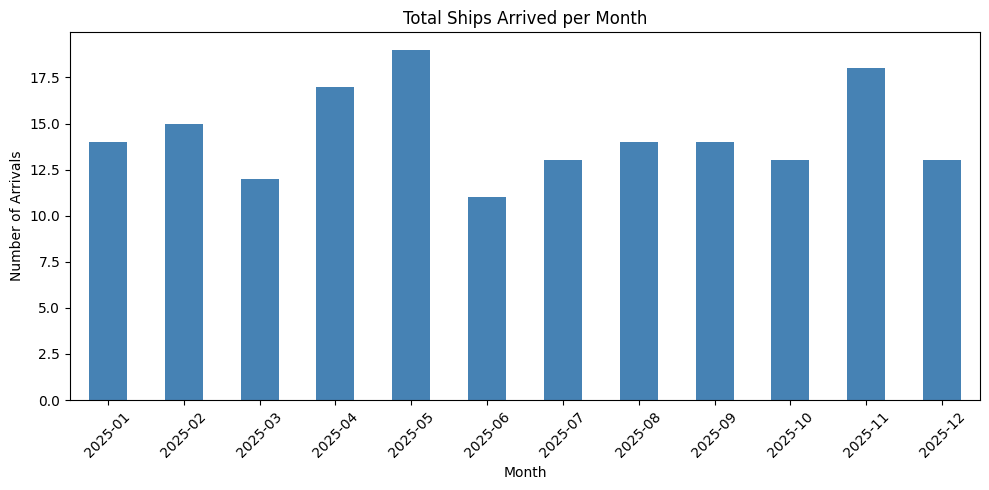

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure datetime
ships_schedule["arrival_dt"] = pd.to_datetime(ships_schedule["arrival_dt"], errors="coerce")

# Count arrivals per month
monthly_arrivals = (
    ships_schedule
    .dropna(subset=["arrival_dt"])
    .groupby(ships_schedule["arrival_dt"].dt.to_period("M"))
    .size()
    .rename("arrivals")
)

# Plot
ax = monthly_arrivals.plot(kind="bar", figsize=(10, 5), color="steelblue")
ax.set_title("Total Ships Arrived per Month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Arrivals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
import numpy as np
import pandas as pd

# Expected input table: one row per cargo stay with:
# - arrival_dt
# - departure_dt
# - ship_type
# Example source variable: ships_schedule

# 1) Prepare intervals
ships_intervals = ships_schedule[["arrival_dt", "departure_dt", "ship_type"]].copy()
ships_intervals["arrival_dt"] = pd.to_datetime(ships_intervals["arrival_dt"])
ships_intervals["departure_dt"] = pd.to_datetime(ships_intervals["departure_dt"])

# Power by ship (kW)
power_map_kw = {
    "torrlastfartyg": 522*0.22, #dry cargo ship
    "bulklastfartyg": 596*0.22, #bulk cargo ship
    "kemtankfartyg": 900*0.67, #chemical tanker
    "pråm": 50, #small passenger ship
    "oljetankfartyg": 900*0.67, #oil tanker
}
ships_intervals["power_kw"] = ships_intervals["ship_type"].astype(str).str.upper().map(power_map_kw).fillna(900.0)

# 1b) Snap to 15-minute steps (00, 15, 30, 45)
# - arrivals -> previous step (floor)
# - departures -> next step (ceil)
ships_intervals["arrival_dt"] = ships_intervals["arrival_dt"].dt.floor("15min")
ships_intervals["departure_dt"] = ships_intervals["departure_dt"].dt.ceil("15min")

# Optional: drop invalid intervals
ships_intervals = ships_intervals[ships_intervals["departure_dt"] > ships_intervals["arrival_dt"]]

# 2) Define 15-minute window from data
start_step = ships_intervals["arrival_dt"].min().floor("15min")
end_step = ships_intervals["departure_dt"].max().ceil("15min")
step_edges = pd.date_range(start=start_step, end=end_step, freq="15min")

# 3) Build 15-minute occupancy matrix
step_index = step_edges[:-1]
start_col = ships_intervals["arrival_dt"].to_numpy()[:, None]
end_col = ships_intervals["departure_dt"].to_numpy()[:, None]
mask = (step_index.to_numpy()[None, :] >= start_col) & (step_index.to_numpy()[None, :] < end_col)

# Per-ship power multipliers by position in stay:
# - if stay <= 4h: first 15 min = 0.85, last 15 min = 0.85
# - if stay  > 4h:
#   - first 15 min after arrival: 0.425
#   - second 15 min after arrival: 0.85
#   - second-last 15 min before departure: 0.85
#   - last 15 min before departure: 0.425
factors = mask.astype(float)
max_steps_short_stay = int(pd.Timedelta(hours=4) / pd.Timedelta(minutes=15))  # 16 steps

for i in range(factors.shape[0]):
    active_idx = np.flatnonzero(mask[i])
    if active_idx.size == 0:
        continue

    if active_idx.size <= max_steps_short_stay:
        # Short stay profile
        factors[i, active_idx[0]] = 0.85
        factors[i, active_idx[-1]] = 0.85
        continue

    # Long stay profile
    # Arrival ramp
    factors[i, active_idx[0]] = 0.425
    factors[i, active_idx[1]] = 0.85

    # Departure ramp
    factors[i, active_idx[-1]] = 0.425
    factors[i, active_idx[-2]] = 0.85

# Demand per step = sum(power_kW * factor of active ships)
step_energy_kwh = (factors * ships_intervals["power_kw"].to_numpy()[:, None]).sum(axis=0)

# 4) Final dataset: ships_demand
ships_demand = pd.DataFrame({"datetime": step_index, "demand_kW": step_energy_kwh})

ships_demand.head()

,datetime,demand_kW
0,2025-01-02 06:00:00,382.5
1,2025-01-02 06:15:00,765.0
2,2025-01-02 06:30:00,900.0
3,2025-01-02 06:45:00,900.0
4,2025-01-02 07:00:00,900.0


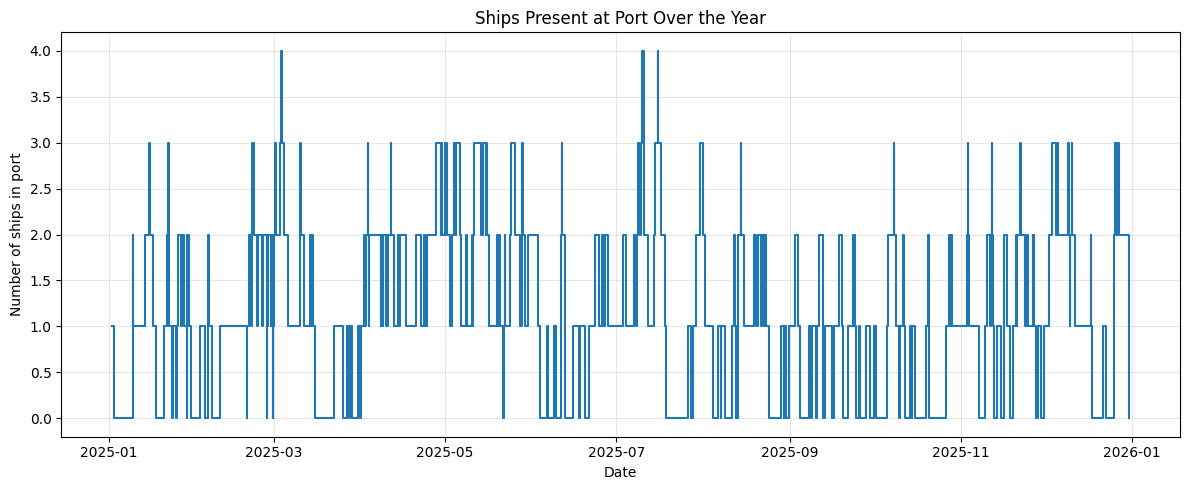

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Keep only valid stays
df = ships_schedule.dropna(subset=["arrival_dt", "departure_dt"]).copy()
df = df[df["departure_dt"] >= df["arrival_dt"]].copy()

# Build +1 event at arrival and -1 event at departure
events = pd.concat([
    df[["arrival_dt"]].rename(columns={"arrival_dt": "time"}).assign(delta=1),
    df[["departure_dt"]].rename(columns={"departure_dt": "time"}).assign(delta=-1),
], ignore_index=True)

# Sort events and compute number of ships in port
events = events.sort_values("time").reset_index(drop=True)
events["ships_in_port"] = events["delta"].cumsum()

# Plot
plt.figure(figsize=(12, 5))
plt.step(events["time"], events["ships_in_port"], where="post")
plt.title("Ships Present at Port Over the Year")
plt.xlabel("Date")
plt.ylabel("Number of ships in port")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# Rebuild clean occupancy time series first
events_clean = (
    events.groupby("time", as_index=True)["delta"]
    .sum()
    .sort_index()
    .to_frame()
)
events_clean["ships_in_port"] = events_clean["delta"].cumsum().clip(lower=0)

# Hourly time series (every hour in the year)
hourly_presence = events_clean["ships_in_port"].resample("1h").ffill()

# 1) Average by hour of day (0..23)
avg_by_hour = hourly_presence.groupby(hourly_presence.index.hour).mean()
avg_by_hour.index.name = "hour"

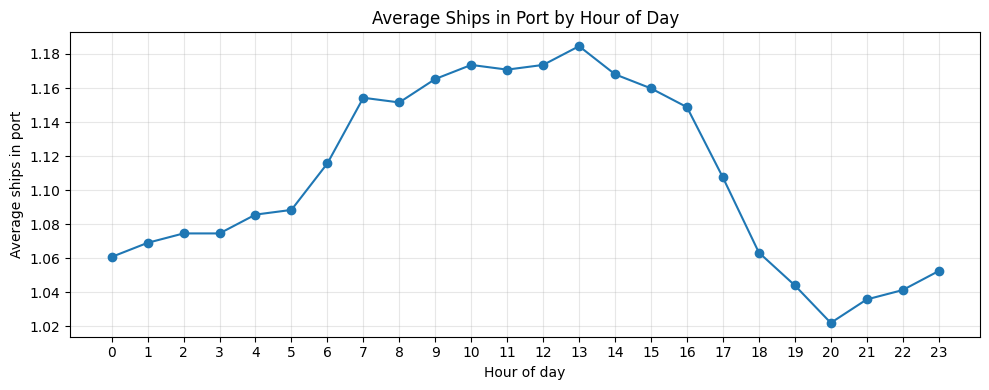

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
avg_by_hour.plot(marker="o")
plt.title("Average Ships in Port by Hour of Day")
plt.xlabel("Hour of day")
plt.ylabel("Average ships in port")
plt.xticks(range(0,24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Optimization using Gurobi

In [19]:
port_operations = pd.read_excel("inputs/Port_Operations.xlsx")
HM_consumptions_full = pd.read_excel("inputs/HM_consumptions_15minutes.xlsx")

Reads price in EUR/MWh and converts them to SEK (1 EUR = 10.77 SEK) and EUR/kWh

In [20]:
# Read CSV from inputs and keep first + fourth columns
da_price = pd.read_excel("inputs/dayahedprices_15min.xlsx").copy()

da_price.head()

,datetime,da_price
0,2025-01-01 00:00:00,0.034111
1,2025-01-01 00:15:00,0.033426
2,2025-01-01 00:30:00,0.034068
3,2025-01-01 00:45:00,0.034528
4,2025-01-01 01:00:00,0.026369


Only taking cargo terminal related vehicles

In [21]:
import pandas as pd

# Normalize all column names in HM_consumptions
HM = HM_consumptions_full.copy()
HM.columns = (
    HM.columns.astype(str)
    .str.replace("\xa0", "", regex=False)   # remove NBSP
    .str.replace(r"\s+", " ", regex=True)   # normalize repeated spaces
    .str.strip()                            # trim edges
)

selected_cols = [
    "Truck 405",
    "Truck 402",
    "Truck 425",
    "Truck 426",
    "Truck 427",
    "Truck 428",
    "Truck 429",
    "Truck 421",
    "Lastmaskin 435",
    "Lastmaskin 437",
    "Lastmaskin 439",
    "Lastmaskin 438",
    "Lastmaskin 433",
    "Lastmaskin 436",
    "Truck 442",
    "Truck 443",
    "Term.drag 471",
    "Term.drag 472",
    "Term.drag 475",
    "Truck 444 Krokmaskin",
]

# Keep datetime if present
keep = ["datetime"] + selected_cols

# Optional safety check
missing = [c for c in keep if c not in HM.columns]
print("Missing:", missing)

# Final filtered dataframe
HM_consumptions_cargoterminal = HM[[c for c in keep if c in HM.columns]].copy()

Missing: []


In [22]:
import numpy as np
import pandas as pd

# -----------------------------
# Assumed existing in notebook:
# - cargoterminal_power_demand: columns ["datetime", "power_kW"]
# - HM_consumptions: columns ["datetime", <vehicle IDs...>] (kWh per hour)
# - port_operations: columns ["ID", "Battery Capacity (kWh)", "Fast Charge Capacity (kW)",
#                             "Requires charging during operation"]
# -----------------------------

# --- Time set T (15-minute) built from cargo terminal + ships demand in kW ---
# cargoterminal_power_demand expected columns: ["datetime", "power_kW"]
base_kw = cargoterminal_power_demand[["datetime", "power_kW"]].copy()
base_kw["datetime"] = pd.to_datetime(base_kw["datetime"], errors="coerce")
base_kw["power_kW"] = pd.to_numeric(base_kw["power_kW"], errors="coerce")
base_kw = (
    base_kw
    .dropna(subset=["datetime"])
    .drop_duplicates(subset=["datetime"])
    .sort_values("datetime")
)

# ships_demand expected to provide one of: demand_kW, demand_kWh, demand_mwh, energy_kWh
ships_kw = ships_demand.copy()
ships_kw["datetime"] = pd.to_datetime(ships_kw["datetime"], errors="coerce")

if "demand_kW" in ships_kw.columns:
    ships_kw["ships_kW"] = pd.to_numeric(ships_kw["demand_kW"], errors="coerce")

ships_kw = (
    ships_kw[["datetime", "ships_kW"]]
    .dropna(subset=["datetime"])
    .drop_duplicates(subset=["datetime"])
    .sort_values("datetime")
)

# Merge timestep-by-timestep at 15-minute resolution
full_idx = pd.date_range(
    start=min(base_kw["datetime"].min(), ships_kw["datetime"].min()),
    end=max(base_kw["datetime"].max(), ships_kw["datetime"].max()),
    freq="15min"
)

T_df = (
    pd.DataFrame({"datetime": full_idx})
    .merge(base_kw, on="datetime", how="left")
    .merge(ships_kw, on="datetime", how="left")
)
T_df["power_kW"] = T_df["power_kW"].fillna(0.0)
T_df["ships_kW"] = T_df["ships_kW"].fillna(0.0)
T_df["total_kW"] = T_df["power_kW"] + T_df["ships_kW"]

T = T_df["datetime"].to_list()

# Fixed terminal demand D[t] in kW
D_kw = T_df.set_index("datetime")["total_kW"].to_dict()

# Helpful index maps
t2i = {t: i for i, t in enumerate(T)}
i2t = {i: t for t, i in t2i.items()}

# --- Vehicle set V from port_operations (Step 24=C) ---
po = port_operations.copy()
po["ID"] = po["ID"].astype(str)

# drop duplicates just in case
po = po.drop_duplicates(subset=["ID"], keep="first").set_index("ID")

V = po.index.to_list()

# Vehicle parameters
Cap_kwh = po["Battery Capacity (kWh)"].astype(float).to_dict()

eligible = (
    po["Requires charging during operation"]
    .notna()
    .to_dict()
)

Pfast_kw = po["Fast Charge Capacity (kW)"].astype(float).fillna(0.0).to_dict()

# --- Consumption Econs[v,t] (kWh) aligned to V x T ---
hm = HM_consumptions_cargoterminal.copy()
hm["datetime"] = pd.to_datetime(hm["datetime"])
hm = hm.dropna(subset=["datetime"]).drop_duplicates(subset=["datetime"]).set_index("datetime").sort_index()

# Reindex to T and ensure all vehicles exist as columns (missing -> 0)
hm = hm.reindex(T, fill_value=0.0)
for v in V:
    if v not in hm.columns:
        hm[v] = 0.0

# Keep only vehicles in V (extra columns ignored)
hm = hm[V].astype(float)

# Dict keyed by (v,t) for easy modeling
Econs_kwh = {(v, t): float(hm.loc[t, v]) for t in T for v in V}

# --- Time window masks ---
slow_hours = {20, 21, 22, 23, 0, 1, 2, 3, 4, 5, 6}   # do NOT include 7
fast_hours = {9, 12, 15}                              # 9-10, 12-13, 15-16

is_slow = {t: (t.hour in slow_hours) for t in T}
is_fast = {t: (t.hour in fast_hours) for t in T}
is_allowed = {t: (is_slow[t] or is_fast[t]) for t in T}

T07 = [t for t in T if (t.hour == 7 and t.minute == 0)]

# --- Sanity checks ---
print(f"|T| = {len(T)} 15 minutes steps from {T[0]} to {T[-1]}")
print(f"|V| = {len(V)} vehicles")
print(f"07:00 checkpoints in T: {len(T07)}")
print(f"Allowed charging hours in T: {sum(is_allowed.values())} (slow={sum(is_slow.values())}, fast={sum(is_fast.values())})")

# Verify no consumption after 20:00 (per your assumption)
after20 = [(v, t, Econs_kwh[(v, t)]) for t in T if t.hour >= 20 for v in V if Econs_kwh[(v, t)] > 0]
print(f"Consumption entries with hour>=20 and >0 kWh: {len(after20)}")
if after20:
    print("Example:", after20[0])

|T| = 35040 15 minutes steps from 2025-01-01 00:00:00 to 2025-12-31 23:45:00
|V| = 32 vehicles
07:00 checkpoints in T: 365
Allowed charging hours in T: 20440 (slow=16060, fast=4380)
Consumption entries with hour>=20 and >0 kWh: 0


In [23]:
from gurobipy import GRB

# -----------------------------
# Uses objects created earlier:
# T, V, t2i, i2t
# D_kw, Cap_kwh, eligible, Pfast_kw
# Econs_kwh
# is_slow, is_fast, is_allowed
# T07
# -----------------------------

P_slow = 22.0  # kW
dt = 0.25      # hour (15-minute timestep)
FAST_LIMIT = 5
SOC_MIN_FRAC = 0.10
SOC_MAX_FRAC = 1.0
# Special rules for high-consumption Truck 444:
# - never skip intraday charging when SOC > 50%
# - may charge at fast power whenever idle (any hour)
INTRADAY_SKIP_EXEMPT_VEHICLE = "Truck 444 Krokmaskin"

# Precompute index helpers
T_idx = list(range(len(T)))
T07_i = sorted(t2i[t] for t in T07)
T07_set = set(T07_i)

next_07_by_i = {}
next_07 = None
for i in reversed(T_idx):
    if i in T07_set:
        next_07 = i
    next_07_by_i[i] = next_07


class DummyVar:
    def __init__(self, x=0.0):
        self.X = float(x)


class DummyModel:
    def __init__(self):
        self.Status = GRB.OPTIMAL
        self.SolCount = 1


# Keep same interface as Gurobi vars used by downstream cells
P = {(v, i): DummyVar(0.0) for v in V for i in T_idx}
SOC = {(v, i): DummyVar(0.0) for v in V for i in T_idx}
m = DummyModel()

# Start at full SOC (same as optimized model).
soc_now = {v: float(Cap_kwh[v]) * SOC_MAX_FRAC for v in V}


def _power_for_soc_floor(soc, cons, min_soc, dt_h):
    # Minimum charging power needed this step to stay at/above the SOC floor.
    return max(0.0, (min_soc + cons - soc) / dt_h)


def _skip_intraday_charging(v, i):
    # Disabled: skipping fast charging can leave too little energy to cover
    # future consumption under the allowed charging windows.
    return False


def _future_consumption(v, i_start, i_end):
    return sum(float(Econs_kwh[(v, i2t[k])]) for k in range(i_start, i_end))


def _is_idle(v, t):
    return float(Econs_kwh[(v, t)]) <= 0.0


def _remaining_charge_slots(v, i_start, i_end):
    # Truck 444 may charge in any idle timestep (not only slow/fast windows).
    if v == INTRADAY_SKIP_EXEMPT_VEHICLE:
        return [
            k
            for k in range(i_start, i_end)
            if _is_idle(v, i2t[k])
        ]
    return [
        k
        for k in range(i_start, i_end)
        if is_allowed[i2t[k]] and _is_idle(v, i2t[k])
    ]


for i in T_idx:
    t = i2t[i]

    # SOC is stored at start of timestep i
    for v in V:
        SOC[v, i].X = soc_now[v]

    if i in T07_set:
        for v in V:
            target_soc = float(Cap_kwh[v]) * SOC_MAX_FRAC
            if soc_now[v] < target_soc - 1e-6:
                raise RuntimeError(
                    f"Vehicle {v} reached {soc_now[v]:.3f} kWh at {t}, "
                    f"below the 07:00 target of {target_soc:.3f} kWh."
                )

    # Choose which eligible vehicles get fast slots this timestep.
    # Dumb rule: among vehicles that can charge now, prioritize biggest energy deficit.
    fast_candidates = []
    if is_fast[t] and is_allowed[t]:
        for v in V:
            cons = float(Econs_kwh[(v, t)])
            cap = float(Cap_kwh[v])
            target_soc = cap * SOC_MAX_FRAC
            if (
                eligible.get(v, False)
                and cons <= 0.0
                and soc_now[v] < target_soc - 1e-9
                and not _skip_intraday_charging(v, i)
            ):
                fast_candidates.append((target_soc - soc_now[v], v))

    fast_candidates.sort(reverse=True)
    fast_set = {v for _, v in fast_candidates[:FAST_LIMIT]}
    # Always reserve a fast slot for Truck 444 when it needs charge at a fast timestep.
    v_ex = INTRADAY_SKIP_EXEMPT_VEHICLE
    if (
        is_fast[t]
        and is_allowed[t]
        and eligible.get(v_ex, False)
        and _is_idle(v_ex, t)
        and soc_now[v_ex] < float(Cap_kwh[v_ex]) * SOC_MAX_FRAC - 1e-9
    ):
        fast_set.add(v_ex)

    # Earliest-possible charging, with extra push before the next 07:00 checkpoint.
    for v in V:
        cap = float(Cap_kwh[v])
        min_soc = cap * SOC_MIN_FRAC
        target_soc = cap * SOC_MAX_FRAC
        cons = float(Econs_kwh[(v, t)])

        if cons > 0.0 and soc_now[v] - cons < min_soc - 1e-6:
            raise RuntimeError(
                f"Vehicle {v} cannot cover consumption at {t}: "
                f"SOC={soc_now[v]:.3f} kWh, cons={cons:.3f} kWh, min={min_soc:.3f} kWh."
            )

        if v == INTRADAY_SKIP_EXEMPT_VEHICLE:
            # Charge whenever idle, at full fast power (matches separate 444 optimization).
            if not _is_idle(v, t):
                p_cap = 0.0
            else:
                p_cap = float(Pfast_kw.get(v, P_slow))
        elif (not is_allowed[t]) or (cons > 0.0):
            p_cap = 0.0
        elif is_slow[t]:
            p_cap = P_slow
        elif is_fast[t]:
            if eligible.get(v, False) and (v in fast_set):
                p_cap = float(Pfast_kw.get(v, P_slow))
            else:
                p_cap = P_slow
        else:
            p_cap = 0.0

        if is_fast[t] and _skip_intraday_charging(v, i):
            p_cap = 0.0

        max_by_headroom = max(0.0, (target_soc - soc_now[v]) / dt)
        p = min(p_cap, max_by_headroom)
        p_floor = _power_for_soc_floor(soc_now[v], cons, min_soc, dt)
        if p_floor > p_cap + 1e-6 and cons <= 0.0:
            raise RuntimeError(
                f"Vehicle {v} needs {p_floor:.3f} kW at {t} to respect the SOC floor, "
                f"but only {p_cap:.3f} kW is available."
            )
        p = min(p_cap, max_by_headroom, max(p, p_floor))

        next07 = next_07_by_i.get(i)
        if next07 is not None and i < next07:
            future_cons = _future_consumption(v, i, next07)
            shortfall_energy = target_soc - (soc_now[v] - future_cons)
            if shortfall_energy > 1e-9:
                remaining_slots = _remaining_charge_slots(v, i, next07)
                if remaining_slots:
                    p_needed = shortfall_energy / (dt * len(remaining_slots))
                    p_needed = shortfall_energy / (dt * len(remaining_slots))
                    if _is_idle(v, t):
                        p = min(p_cap, max_by_headroom, max(p, p_needed))

        P[v, i].X = float(p)

        soc_next = soc_now[v] + p * dt - cons
        if soc_next < min_soc - 1e-6:
            raise RuntimeError(
                f"Vehicle {v} violated the SOC floor at {t}: "
                f"SOC_next={soc_next:.3f} kWh, min={min_soc:.3f} kWh."
            )
        soc_now[v] = min(target_soc, soc_next)

# Diagnostics similar to old cell
p_peak = max(float(D_kw[i2t[i]]) + sum(P[v, i].X for v in V) for i in T_idx)
total_energy = sum(P[v, i].X * dt for v in V for i in T_idx)
total_consumption = sum(float(Econs_kwh[(v, i2t[i])]) for v in V for i in T_idx)

if m.Status == GRB.OPTIMAL:
    print("P_peak (kW):", float(p_peak))
    print("Total charged energy (kWh):", float(total_energy))
    print("Total consumption (kWh):", float(total_consumption))
    print("Energy balance gap (kWh):", float(total_energy - total_consumption))
    print(f"07:00 SOC checkpoints enforced: {len(T07_i)}")
else:
    print("Scheduler status:", m.Status)

P_peak (kW): 5228.363448000388
Total charged energy (kWh): 1548698.375
Total consumption (kWh): 1548968.75
Energy balance gap (kWh): -270.375
07:00 SOC checkpoints enforced: 365


In [37]:
# Build timestamp -> price mapping aligned to model timesteps T
price_df = da_price.copy()
price_df["datetime"] = pd.to_datetime(price_df["datetime"], errors="coerce").dt.tz_localize(None)
price_df["da_price"] = pd.to_numeric(price_df["da_price"], errors="coerce")

price_series = (
    price_df.dropna(subset=["datetime", "da_price"])
            .sort_values("datetime")
            .drop_duplicates("datetime", keep="last")
            .set_index("datetime")["da_price"]
)

t_index = pd.DatetimeIndex(pd.to_datetime(T)).tz_localize(None)
price_on_T = price_series.reindex(t_index).ffill().bfill()

if price_on_T.isna().any():
    missing = list(price_on_T[price_on_T.isna()].index[:10])
    raise ValueError(f"Missing da_price for timestamps (examples): {missing}")

price_t = {t: float(v) for t, v in zip(T, price_on_T.values)}

In [25]:
total_charging_cost = sum(
    P[v, i].X * dt * price_t[i2t[i]]
    for v in V
    for i in T_idx
)

print("Total charging cost:", (float(1.0561*total_charging_cost)+float(0.025*total_energy)))

Total charging cost: 879676.1101852308


In [38]:
import pandas as pd

EV_ZERO_TOL = 1.0000001111620804e-06  # numerical noise at peak

def compute_peak_impact_metrics(df):
    df = df.copy()
    df["datetime"] = pd.to_datetime(df["datetime"])

    # Treat negligible EV as exactly zero
    if "EV_charging_kw" in df.columns:
        ev_kw = df["EV_charging_kw"].where(
            df["EV_charging_kw"].abs() > EV_ZERO_TOL, 0.0
        )
    else:
        ev_kw = df["total_kW"] - (
            df["base_demand_kw"] + df["shore_power_demand_kw"]
        )

    load_no = df["base_demand_kw"] + df["shore_power_demand_kw"]
    load_with = load_no + ev_kw  # rebuild total from cleaned EV

    idx_peak_with = load_with.idxmax()

    peak_no = float(load_no.max())
    peak_with = float(load_with.max())
    peak_increase = peak_with - peak_no

    if abs(peak_increase) <= EV_ZERO_TOL:
        peak_increase = 0.0
        peak_with = peak_no

    return {
        "peak_no_charging_kw": peak_no,
        "peak_with_charging_kw": peak_with,
        "peak_increase_kw": peak_increase,
        "ev_kw_at_system_peak": float(ev_kw.loc[idx_peak_with]),
    }

# Load cargo-terminal results
if "df_opt" not in globals():
    if "load_optimization_results" in globals():
        df_opt = load_optimization_results()
    else:
        df_opt = pd.read_excel("outputs/dumb_cargoterminal_loadshifting.xlsx")

peak_summary = compute_peak_impact_metrics(df_opt)
print(peak_summary)

{'peak_no_charging_kw': 3813.9082747500806, 'peak_with_charging_kw': 5228.363448000388, 'peak_increase_kw': 1414.4551732503078, 'ev_kw_at_system_peak': 1579.0}


## 4. Results export and visualization

In [27]:
# Day-by-day charging difference vs optimized model (requires both exports in outputs/)
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

DT_H = 0.25
OPT_PATH = Path("outputs/new_cargoterminal_loadshifting.xlsx")
DUMB_PATH = Path("outputs/dumb_cargoterminal_loadshifting.xlsx")
COMPARE_OUT = "outputs/daily_charging_comparison.xlsx"

if OPT_PATH.is_file() and DUMB_PATH.is_file():
    def _daily(path, label):
        df = pd.read_excel(path)
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
        df = df.dropna(subset=["datetime"]).sort_values("datetime")
        kw = pd.to_numeric(df["EV_charging_kw"], errors="coerce").fillna(0).clip(lower=0)
        return (kw * DT_H).groupby(df["datetime"].dt.floor("D")).sum().rename(f"charging_kwh_{label}")

    cmp = pd.concat([_daily(OPT_PATH, "optimized"), _daily(DUMB_PATH, "dumb")], axis=1).fillna(0)
    cmp = cmp.reset_index().rename(columns={"datetime": "date"})
    cmp["diff_kwh"] = cmp["charging_kwh_optimized"] - cmp["charging_kwh_dumb"]
    cmp["cum_diff_kwh"] = cmp["diff_kwh"].cumsum()
    os.makedirs("outputs", exist_ok=True)
    cmp.to_excel(COMPARE_OUT, index=False)
    print("Top 5 days by |diff|:")
    print(cmp.reindex(cmp["diff_kwh"].abs().nlargest(5).index)[["date","charging_kwh_optimized","charging_kwh_dumb","diff_kwh"]])
    print(f"\nSaved: {COMPARE_OUT}")
else:
    print("Run optimized notebook export first to build daily comparison.")

Top 5 days by |diff|:
          date  charging_kwh_optimized  charging_kwh_dumb     diff_kwh
277 2025-10-05             5367.058394        4052.550000  1314.508394
164 2025-06-14             5459.518228        4169.736475  1289.781752
249 2025-09-07             5368.880225        4086.171698  1282.708528
88  2025-03-30             5241.337636        4028.558050  1212.779586
242 2025-08-31             5224.755813        4033.925000  1190.830813

Saved: outputs/daily_charging_comparison.xlsx


In [28]:
import pandas as pd
from pathlib import Path
import os

# Build demand components at 15-minute resolution:
# datetime, base demand, shore power demand, EV charging, total.
if "T_df" not in globals():
    raise RuntimeError("T_df was not found. Run the time-series preparation cells first.")

base_by_dt = T_df.set_index("datetime")["power_kW"].to_dict()
shore_by_dt = T_df.set_index("datetime")["ships_kW"].to_dict()

rows = []
for i in T_idx:
    t = pd.to_datetime(i2t[i])
    ev_charge_kw = float(sum(P[v, i].X for v in V))

    base_kw = float(base_by_dt.get(t, 0.0))
    shore_kw = float(shore_by_dt.get(t, 0.0))
    total_kw = base_kw + shore_kw + ev_charge_kw

    rows.append({
        "datetime": t,
        "base_demand_kw": base_kw,
        "shore_power_demand_kw": shore_kw,
        "EV_charging_kw": ev_charge_kw,
        "total_kW": total_kw,
    })

out_df = pd.DataFrame(rows).sort_values("datetime").reset_index(drop=True)

# Cursor/VS Code notebook runtime variable
nb_file = globals().get("__vsc_ipynb_file__")
if not nb_file:
    raise RuntimeError(
        "Notebook filename is not exposed in this runtime (__vsc_ipynb_file__ missing)."
    )

notebook_base = Path(nb_file).stem
output_file = f"outputs/{notebook_base}.xlsx"

os.makedirs("outputs", exist_ok=True)
out_df.to_excel(output_file, index=False)

print(f"Saved: {output_file}")

Saved: outputs/dumb_cargoterminal_loadshifting.xlsx


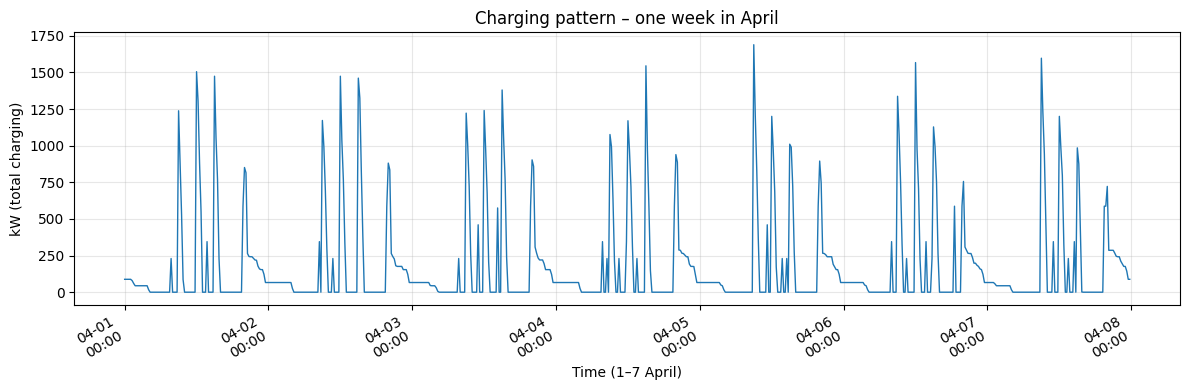

In [29]:
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Same base series
x_all = [i2t[i] for i in T_idx]
p_total_all = [float(sum(P[v, i].X for v in V)) for i in T_idx]

# Define one week in April (here: 1–7 April)
year = x_all[0].year  # assumes all in same year
start = dt.datetime(year, 4, 1)
end   = dt.datetime(year, 4, 8)  # exclusive upper bound

x_week = []
p_week = []
for t, p in zip(x_all, p_total_all):
    if start <= t < end:
        x_week.append(t)
        p_week.append(p)

plt.figure(figsize=(12, 4))
plt.plot(x_week, p_week, lw=1, color="tab:blue")

plt.ylabel("kW (total charging)")
plt.xlabel("Time (1–7 April)")
plt.title("Charging pattern – one week in April")
plt.grid(True, alpha=0.3)

plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H:%M"))
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

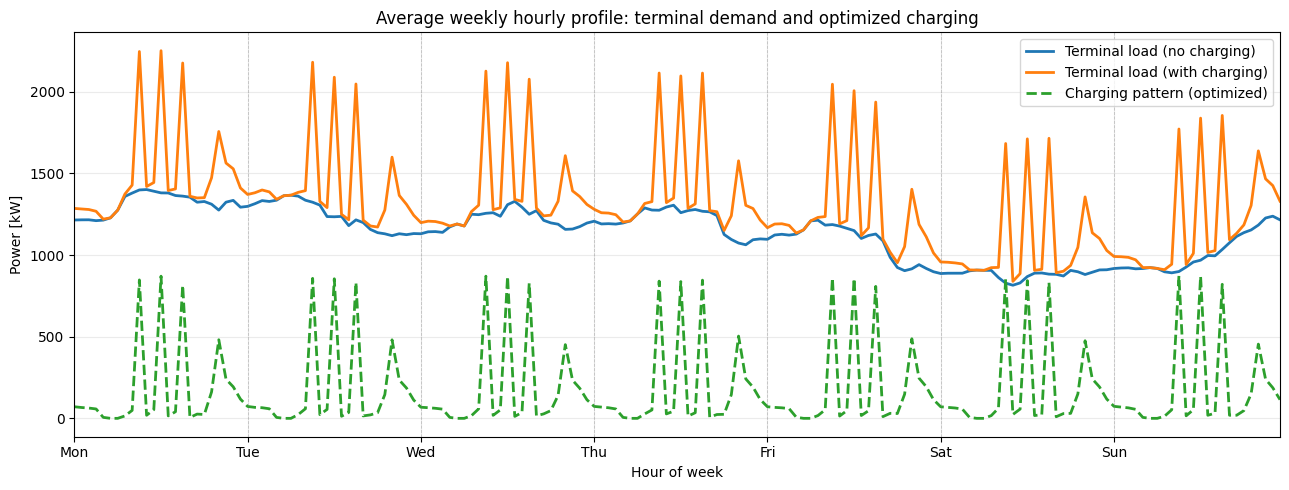

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

REQUIRED_COLS = (
    "datetime",
    "base_demand_kw",
    "shore_power_demand_kw",
    "total_kW",
)


def load_optimization_results():
    if "out_df" in globals():
        candidate = out_df.copy()
        if all(col in candidate.columns for col in REQUIRED_COLS):
            return candidate

    notebook_dir = None
    nb_file = globals().get("__vsc_ipynb_file__")
    if nb_file:
        notebook_dir = Path(nb_file).resolve().parent

    search_paths = []
    if "output_file" in globals():
        search_paths.append(Path(output_file))
    if notebook_dir is not None:
        search_paths.append(notebook_dir / "outputs" / "dumb_cargoterminal_loadshifting.xlsx")

    seen = set()
    for path in search_paths:
        resolved = path.expanduser()
        if not resolved.is_absolute() and notebook_dir is not None:
            resolved = notebook_dir / resolved
        resolved = resolved.resolve()
        if resolved in seen:
            continue
        seen.add(resolved)
        if not resolved.is_file():
            continue

        candidate = pd.read_excel(resolved)
        missing = [col for col in REQUIRED_COLS if col not in candidate.columns]
        if missing:
            raise KeyError(
                f"{resolved} is missing columns {missing}. Found: {list(candidate.columns)}"
            )
        return candidate

    raise RuntimeError(
        "Optimization export not found. Run the results export cell first, "
        "or place dumb_cargoterminal_loadshifting.xlsx in the outputs/ folder next to this notebook."
    )


df_opt = load_optimization_results()

# 1) Clean datetime
df_opt["datetime"] = pd.to_datetime(df_opt["datetime"], errors="coerce")
df_opt = df_opt.dropna(subset=["datetime"]).sort_values("datetime")

# 2) Terminal load with and without optimized EV charging
df_opt["terminal_load_no_charging_kw"] = (
    df_opt["base_demand_kw"] + df_opt["shore_power_demand_kw"]
)
df_opt["terminal_load_with_charging_kw"] = df_opt["total_kW"]
df_opt["charging_kw"] = (
    df_opt["terminal_load_with_charging_kw"] - df_opt["terminal_load_no_charging_kw"]
).clip(lower=0)

# 3) Hour of week (0..167)
df_opt["hour_of_week"] = df_opt["datetime"].dt.dayofweek * 24 + df_opt["datetime"].dt.hour

# 4) Weekly average profiles
weekly = (
    df_opt.groupby("hour_of_week")[[
        "terminal_load_no_charging_kw",
        "terminal_load_with_charging_kw",
        "charging_kw"
    ]]
    .mean()
    .reindex(range(168))
    .reset_index()
)

# 5) Plot combined
plt.figure(figsize=(13, 5))

plt.plot(
    weekly["hour_of_week"],
    weekly["terminal_load_no_charging_kw"],
    label="Terminal load (no charging)",
    linewidth=2
)

plt.plot(
    weekly["hour_of_week"],
    weekly["terminal_load_with_charging_kw"],
    label="Terminal load (with charging)",
    linewidth=2
)

plt.plot(
    weekly["hour_of_week"],
    weekly["charging_kw"],
    label="Charging pattern (optimized)",
    linewidth=2,
    linestyle="--"
)

# Day separators
day_starts = [0, 24, 48, 72, 96, 120, 144]
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
for x in day_starts:
    plt.axvline(x=x, color="gray", linestyle="--", linewidth=0.6, alpha=0.4)

plt.xticks(day_starts, day_labels)
plt.xlim(0, 167)
plt.xlabel("Hour of week")
plt.ylabel("Power [kW]")
plt.title("Average weekly hourly profile: terminal demand and optimized charging")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

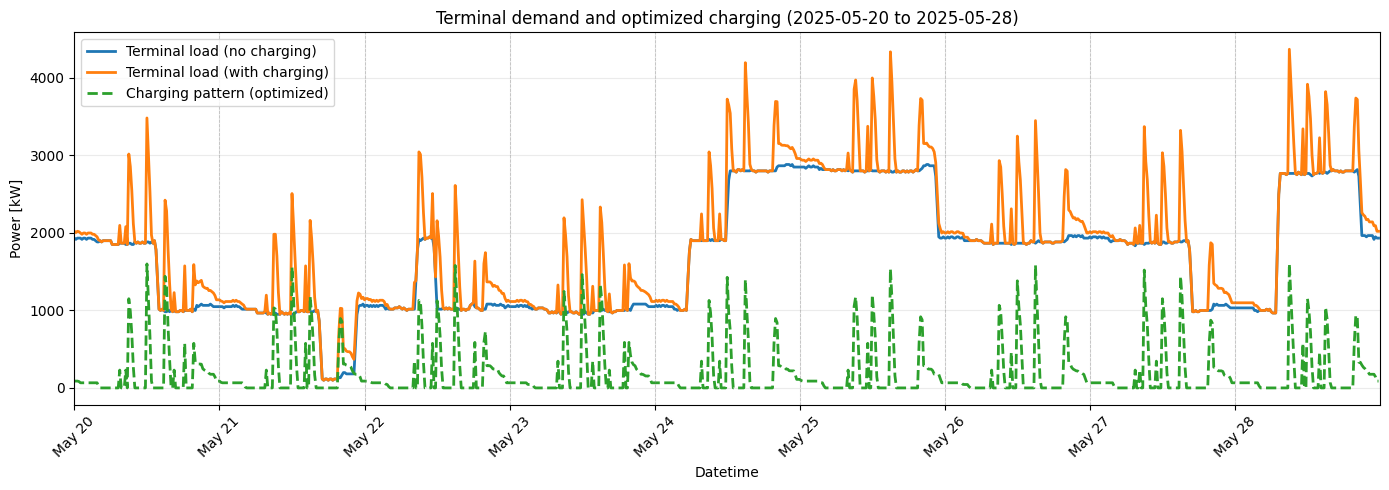

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

if "df_opt" not in globals() or "terminal_load_with_charging_kw" not in df_opt.columns:
    df_opt = load_optimization_results()
    df_opt["datetime"] = pd.to_datetime(df_opt["datetime"], errors="coerce")
    df_opt = df_opt.dropna(subset=["datetime"]).sort_values("datetime")
    df_opt["terminal_load_no_charging_kw"] = (
        df_opt["base_demand_kw"] + df_opt["shore_power_demand_kw"]
    )
    df_opt["terminal_load_with_charging_kw"] = df_opt["total_kW"]
    df_opt["charging_kw"] = (
        df_opt["terminal_load_with_charging_kw"] - df_opt["terminal_load_no_charging_kw"]
    ).clip(lower=0)

# Filter exact period (inclusive start, inclusive end date)
start = pd.Timestamp("2025-05-20 00:00:00")
end   = pd.Timestamp("2025-05-28 23:59:59")
period = df_opt[(df_opt["datetime"] >= start) & (df_opt["datetime"] <= end)].copy()

if period.empty:
    print("No data found in the selected period.")
else:
    plt.figure(figsize=(14, 5))

    plt.plot(
        period["datetime"],
        period["terminal_load_no_charging_kw"],
        label="Terminal load (no charging)",
        linewidth=2
    )

    plt.plot(
        period["datetime"],
        period["terminal_load_with_charging_kw"],
        label="Terminal load (with charging)",
        linewidth=2
    )

    plt.plot(
        period["datetime"],
        period["charging_kw"],
        label="Charging pattern (optimized)",
        linewidth=2,
        linestyle="--"
    )

    # Day separators + daily ticks
    day_starts = pd.date_range(start=start.normalize(), end=end.normalize(), freq="D")
    for x in day_starts:
        plt.axvline(x=x, color="gray", linestyle="--", linewidth=0.6, alpha=0.4)

    plt.xticks(day_starts, [d.strftime("%b %d") for d in day_starts], rotation=45)
    plt.xlim(start, end)
    plt.xlabel("Datetime")
    plt.ylabel("Power [kW]")
    plt.title("Terminal demand and optimized charging (2025-05-20 to 2025-05-28)")
    plt.grid(True, alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

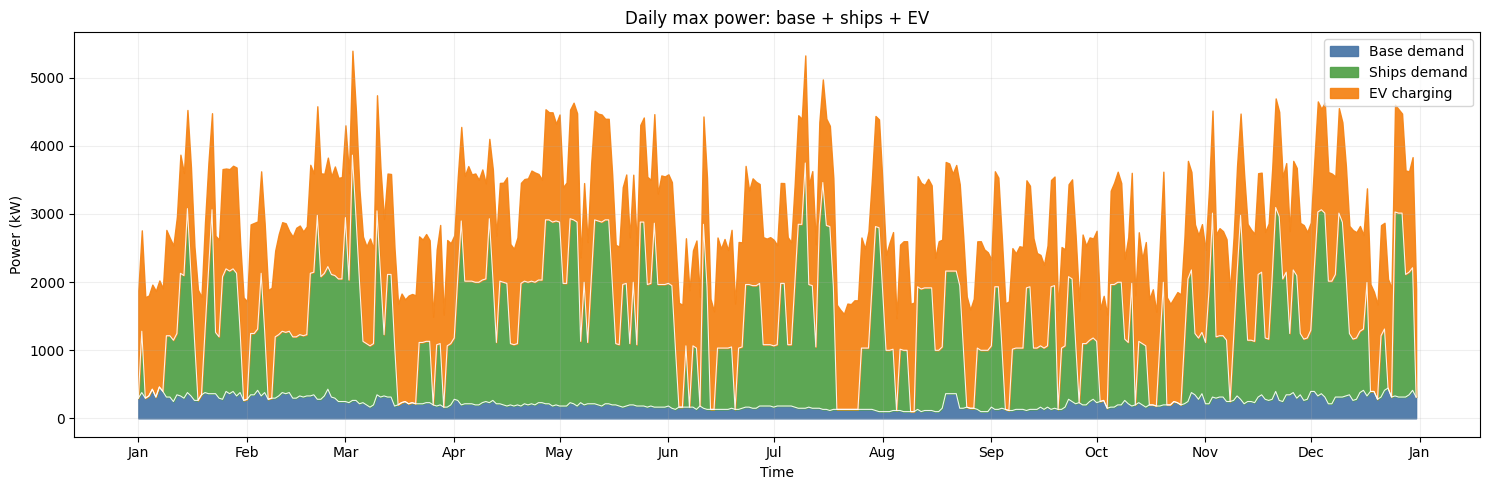

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

file_path = "outputs/dumb_cargoterminal_loadshifting.xlsx"

TIME_COL = "datetime"
BASE_COL = "base_demand_kw"
SHIP_COL = "shore_power_demand_kw"
EV_COL   = "EV_charging_kw"

df = pd.read_excel(file_path)
df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
df = df.dropna(subset=[TIME_COL]).sort_values(TIME_COL)

df[BASE_COL] = pd.to_numeric(df[BASE_COL], errors="coerce").fillna(0).clip(lower=0)
df[SHIP_COL] = pd.to_numeric(df[SHIP_COL], errors="coerce").fillna(0).clip(lower=0)
df[EV_COL]   = pd.to_numeric(df[EV_COL], errors="coerce").fillna(0).clip(lower=0)

# Daily aggregation
d = (df.set_index(TIME_COL)[[BASE_COL, SHIP_COL, EV_COL]]
       .resample("D").max()
       .reset_index())

# Cumulative levels
base_top = d[BASE_COL]
ship_top = d[BASE_COL] + d[SHIP_COL]
total    = d[BASE_COL] + d[SHIP_COL] + d[EV_COL]

fig, ax = plt.subplots(figsize=(15, 5))

# Level 1: base
ax.fill_between(d[TIME_COL], 0, base_top, color="#4C78A8", alpha=0.95, label="Base demand")

# Level 2: ships
ax.fill_between(d[TIME_COL], base_top, ship_top, color="#54A24B", alpha=0.95, label="Ships demand")

# Level 3: EV
ax.fill_between(d[TIME_COL], ship_top, total, color="#F58518", alpha=0.95, label="EV charging")

# Optional separators
ax.plot(d[TIME_COL], base_top, color="white", lw=0.8, alpha=0.9)
ax.plot(d[TIME_COL], ship_top, color="white", lw=0.8, alpha=0.9)

ax.set_ylabel("Power (kW)")
ax.set_xlabel("Time")
ax.set_title("Daily max power: base + ships + EV")
ax.legend(loc="upper right")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


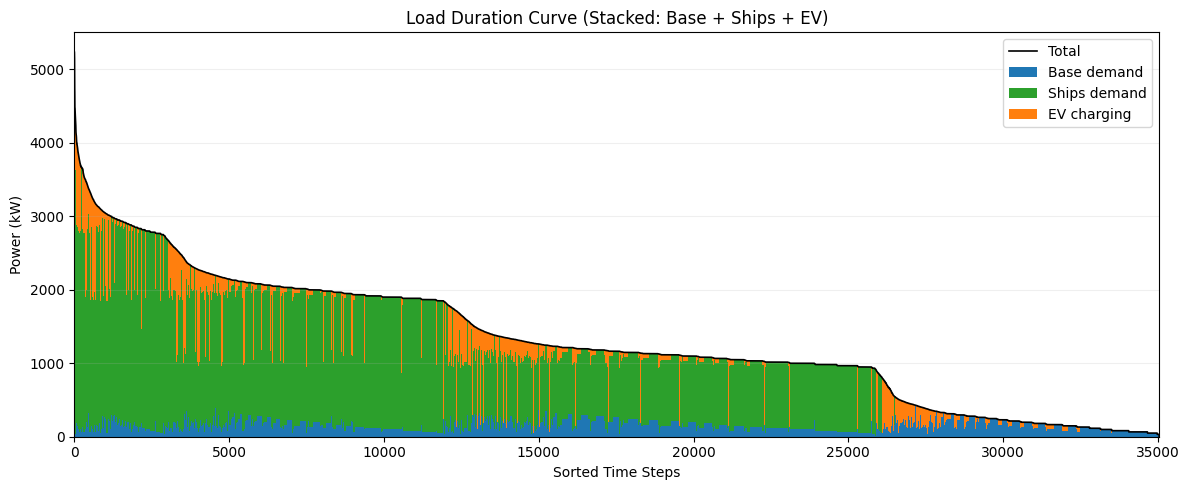

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Input
# ----------------------------

sheet_name = 0

TIME_COL = "datetime"
BASE_COL = "base_demand_kw"
SHIP_COL = "shore_power_demand_kw"
EV_COL   = "EV_charging_kw"

# ----------------------------
# Load and clean
# ----------------------------
df = pd.read_excel(file_path, sheet_name=sheet_name)

df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
df = df.dropna(subset=[TIME_COL])

df[BASE_COL] = pd.to_numeric(df[BASE_COL], errors="coerce").fillna(0).clip(lower=0)
df[SHIP_COL] = pd.to_numeric(df[SHIP_COL], errors="coerce").fillna(0).clip(lower=0)
df[EV_COL]   = pd.to_numeric(df[EV_COL],   errors="coerce").fillna(0).clip(lower=0)

# ----------------------------
# Build load duration data
# ----------------------------
tmp = df[[BASE_COL, SHIP_COL, EV_COL]].copy()
tmp["total"] = tmp[BASE_COL] + tmp[SHIP_COL] + tmp[EV_COL]

# Sort descending by total load (duration curve)
tmp = tmp.sort_values("total", ascending=False).reset_index(drop=True)

# x = sorted time-step index
x = np.arange(len(tmp))

base_sorted  = tmp[BASE_COL].values
ship_sorted  = tmp[SHIP_COL].values
ev_sorted    = tmp[EV_COL].values
base_ship_top = base_sorted + ship_sorted
total_sorted = tmp["total"].values

# ----------------------------
# Plot (stacked, striped style)
# ----------------------------
fig, ax = plt.subplots(figsize=(12, 5))

# Layer 1: base
ax.bar(x, base_sorted, width=1.0, color="#1f77b4", label="Base demand", linewidth=0)

# Layer 2: ships (on top of base)
ax.bar(x, ship_sorted, width=1.0, bottom=base_sorted, color="#2ca02c", label="Ships demand", linewidth=0)

# Layer 3: EV (on top of base+ships)
ax.bar(x, ev_sorted, width=1.0, bottom=base_ship_top, color="#ff7f0e", label="EV charging", linewidth=0)

# Top envelope line
ax.plot(x, total_sorted, color="black", linewidth=1.2, label="Total")

ax.set_title("Load Duration Curve (Stacked: Base + Ships + EV)")
ax.set_xlabel("Sorted Time Steps")
ax.set_ylabel("Power (kW)")
ax.set_xlim(0, len(x) - 1)
ax.set_ylim(0, 5500)
ax.grid(alpha=0.2, axis="y")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

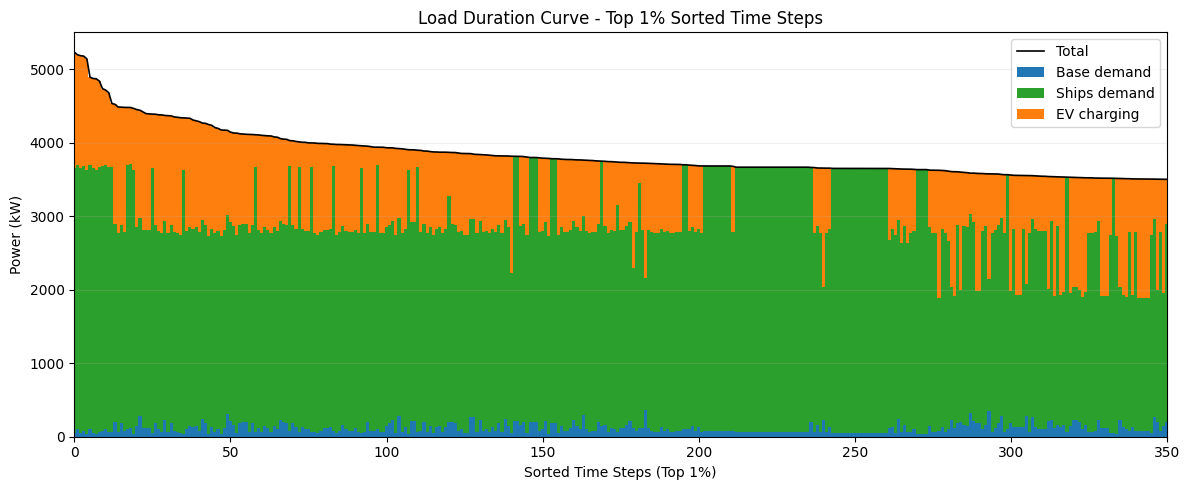

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Input
# ----------------------------

sheet_name = 0

TIME_COL = "datetime"
BASE_COL = "base_demand_kw"
SHIP_COL = "shore_power_demand_kw"
EV_COL   = "EV_charging_kw"

# ----------------------------
# Load and clean
# ----------------------------
df = pd.read_excel(file_path, sheet_name=sheet_name)

df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
df = df.dropna(subset=[TIME_COL])

df[BASE_COL] = pd.to_numeric(df[BASE_COL], errors="coerce").fillna(0).clip(lower=0)
df[SHIP_COL] = pd.to_numeric(df[SHIP_COL], errors="coerce").fillna(0).clip(lower=0)
df[EV_COL]   = pd.to_numeric(df[EV_COL], errors="coerce").fillna(0).clip(lower=0)

# ----------------------------
# Build load duration data
# ----------------------------
tmp = df[[BASE_COL, SHIP_COL, EV_COL]].copy()
tmp["total"] = tmp[BASE_COL] + tmp[SHIP_COL] + tmp[EV_COL]
tmp = tmp.sort_values("total", ascending=False).reset_index(drop=True)

# Keep only top 1% sorted timesteps
n = len(tmp)
top_n = max(1, int(np.ceil(0.01 * n)))
top = tmp.iloc[:top_n].copy()

x = np.arange(top_n)
base_sorted = top[BASE_COL].values
ship_sorted = top[SHIP_COL].values
ev_sorted   = top[EV_COL].values
base_ship_top = base_sorted + ship_sorted
total_sorted = top["total"].values

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x, base_sorted, width=1.0, color="#1f77b4", label="Base demand", linewidth=0)
ax.bar(x, ship_sorted, width=1.0, bottom=base_sorted, color="#2ca02c", label="Ships demand", linewidth=0)
ax.bar(x, ev_sorted,   width=1.0, bottom=base_ship_top, color="#ff7f0e", label="EV charging", linewidth=0)
ax.plot(x, total_sorted, color="black", linewidth=1.2, label="Total")

ax.set_title("Load Duration Curve - Top 1% Sorted Time Steps")
ax.set_xlabel("Sorted Time Steps (Top 1%)")
ax.set_ylabel("Power (kW)")
ax.set_xlim(0, top_n - 1)
ax.set_ylim(0, 5500)
ax.grid(alpha=0.2, axis="y")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()


Selected week: 2025-10-13/2025-10-19 (price range = 5.494 EUR/kWh)


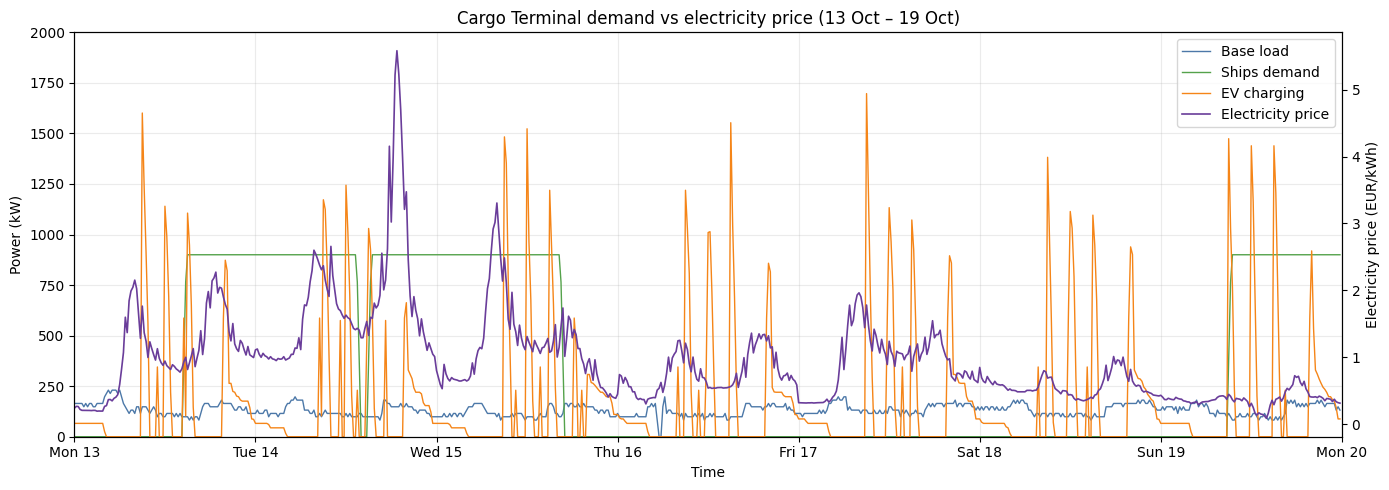

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

file_path = "outputs/dumb_cargoterminal_loadshifting.xlsx"

TIME_COL = "datetime"
BASE_COL = "base_demand_kw"
SHIP_COL = "shore_power_demand_kw"   # ships shore power (same data as ferry OPS_COL)
EV_COL = "EV_charging_kw"
PRICE_COL = "da_price"

# Load demand components
if "out_df" in globals():
    df = out_df[[TIME_COL, BASE_COL, SHIP_COL, EV_COL]].copy()
else:
    df = pd.read_excel(file_path)[[TIME_COL, BASE_COL, SHIP_COL, EV_COL]].copy()

df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
for col in [BASE_COL, SHIP_COL, EV_COL]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).clip(lower=0)

# Load electricity price
price = da_price[[TIME_COL, PRICE_COL]].copy()
price[TIME_COL] = pd.to_datetime(price[TIME_COL], errors="coerce")
price[PRICE_COL] = pd.to_numeric(price[PRICE_COL], errors="coerce")

plot_df = df.merge(price, on=TIME_COL, how="inner").sort_values(TIME_COL)

# Pick week with largest price fluctuation
plot_df["week"] = plot_df[TIME_COL].dt.to_period("W-SUN")
week_stats = plot_df.groupby("week")[PRICE_COL].agg(lambda s: s.max() - s.min())
selected_week = week_stats.idxmax()
print(f"Selected week: {selected_week} (price range = {week_stats.max():.3f} EUR/kWh)")

week_df = plot_df[plot_df["week"] == selected_week].copy()
start = week_df[TIME_COL].min()
end = week_df[TIME_COL].max() + pd.Timedelta(minutes=15)

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(week_df[TIME_COL], week_df[BASE_COL], color="#4C78A8", linewidth=1.0, label="Base load")
ax1.plot(week_df[TIME_COL], week_df[SHIP_COL], color="#54A24B", linewidth=1.0, label="Ships demand")
ax1.plot(week_df[TIME_COL], week_df[EV_COL], color="#F58518", linewidth=1.0, label="EV charging")

ax1.set_ylabel("Power (kW)")
power_max = week_df[[BASE_COL, SHIP_COL, EV_COL]].max().max()
ax1.set_ylim(0, max(1000, 2000))
ax1.set_xlabel("Time")
ax1.grid(alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(week_df[TIME_COL], week_df[PRICE_COL], color="#6A3D9A", linewidth=1.2, label="Electricity price")
ax2.set_ylabel("Electricity price (EUR/kWh)")  # matches da_price units in this notebook

ax1.set_title(
    f"Cargo Terminal demand vs electricity price "
    f"({start:%d %b} – {end - pd.Timedelta(days=1):%d %b})"
)
ax1.set_xlim(start, end)
ax1.xaxis.set_major_locator(mdates.DayLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%a %d"))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()